# Praktikum Data Mining
## Klasifikasi dengan Naive Bayes & k-Nearest Neighbor (k-NN)

Dataset: **Play Tennis** (kategorikal, 14 baris) dan **Iris** (numerik, 150 baris)

Nama: Harits Tsaqif  |  NIM: 24343009 

## 4.1 Persiapan Lingkungan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB, GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 4.2 Load dan Eksplorasi Dataset Play Tennis

Sel pertama membuat file `play_tennis.csv` secara otomatis jika file tersebut belum ada di folder kerja (data standar Play Tennis 14 baris). Jika Anda sudah punya file dari modul, file itu yang akan dipakai.

In [2]:
import os
if not os.path.exists('play_tennis.csv'):
    data_pt = '''Day,Outlook,Temperature,Humidity,Wind,PlayTennis
D1,Sunny,Hot,High,Weak,No
D2,Sunny,Hot,High,Strong,No
D3,Overcast,Hot,High,Weak,Yes
D4,Rain,Mild,High,Weak,Yes
D5,Rain,Cool,Normal,Weak,Yes
D6,Rain,Cool,Normal,Strong,No
D7,Overcast,Cool,Normal,Strong,Yes
D8,Sunny,Mild,High,Weak,No
D9,Sunny,Cool,Normal,Weak,Yes
D10,Rain,Mild,Normal,Weak,Yes
D11,Sunny,Mild,Normal,Strong,Yes
D12,Overcast,Mild,High,Strong,Yes
D13,Overcast,Hot,Normal,Weak,Yes
D14,Rain,Mild,High,Strong,No
'''
    with open('play_tennis.csv', 'w') as f:
        f.write(data_pt)

df = pd.read_csv('play_tennis.csv')
print(df.head())
print(df['PlayTennis'].value_counts())

  Day   Outlook Temperature Humidity    Wind PlayTennis
0  D1     Sunny         Hot     High    Weak         No
1  D2     Sunny         Hot     High  Strong         No
2  D3  Overcast         Hot     High    Weak        Yes
3  D4      Rain        Mild     High    Weak        Yes
4  D5      Rain        Cool   Normal    Weak        Yes
PlayTennis
Yes    9
No     5
Name: count, dtype: int64


## 4.3 Encoding Fitur Kategorikal

In [3]:
fitur = ['Outlook', 'Temperature', 'Humidity', 'Wind']
X = df[fitur].copy()
y = df['PlayTennis'].copy()

enc = OrdinalEncoder()
X_enc = pd.DataFrame(enc.fit_transform(X), columns=fitur)

for col, cats in zip(fitur, enc.categories_):
    print(f'{col}: {dict(zip(cats, range(len(cats))))}')

Outlook: {'Overcast': 0, 'Rain': 1, 'Sunny': 2}
Temperature: {'Cool': 0, 'Hot': 1, 'Mild': 2}
Humidity: {'High': 0, 'Normal': 1}
Wind: {'Strong': 0, 'Weak': 1}


## 4.4 Membangun Model Naive Bayes pada Play Tennis

In [4]:
clf_nb = CategoricalNB()
clf_nb.fit(X_enc, y)

for cls, logp in zip(clf_nb.classes_, clf_nb.class_log_prior_):
    print(f'P({cls}) = {np.exp(logp):.4f}')

P(No) = 0.3571
P(Yes) = 0.6429


## 4.5 Prediksi Data Baru dengan Naive Bayes

In [5]:
data_baru = pd.DataFrame([{
    'Outlook': 'Sunny', 'Temperature': 'Cool',
    'Humidity': 'High', 'Wind': 'Strong'
}])
data_baru_enc = pd.DataFrame(enc.transform(data_baru), columns=fitur)

pred = clf_nb.predict(data_baru_enc)
proba = clf_nb.predict_proba(data_baru_enc)
print('Prediksi:', pred[0])
print('Probabilitas:', {str(c): float(p) for c, p in zip(clf_nb.classes_, proba[0].round(4))})

Prediksi: No
Probabilitas: {'No': 0.7201, 'Yes': 0.2799}


## 4.6 Naive Bayes pada Dataset Iris (Train/Test Split)

In [6]:
iris = load_iris()
Xi = pd.DataFrame(iris.data, columns=iris.feature_names)
yi = iris.target

Xi_train, Xi_test, yi_train, yi_test = train_test_split(
    Xi, yi, test_size=0.3, random_state=42, stratify=yi)

nb = GaussianNB()
nb.fit(Xi_train, yi_train)
nb_pred = nb.predict(Xi_test)

print('Akurasi:', accuracy_score(yi_test, nb_pred))
print(classification_report(yi_test, nb_pred, target_names=iris.target_names, digits=3))

Akurasi: 0.9111111111111111
              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        15
  versicolor      0.824     0.933     0.875        15
   virginica      0.923     0.800     0.857        15

    accuracy                          0.911        45
   macro avg      0.916     0.911     0.911        45
weighted avg      0.916     0.911     0.911        45



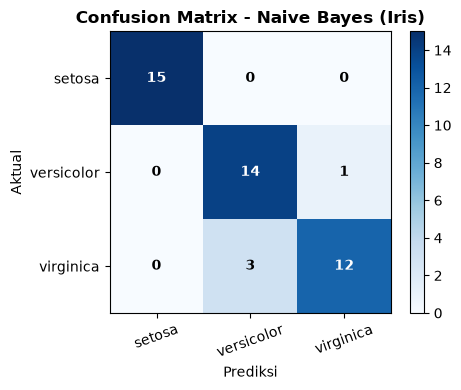

In [ ]:
cm_nb = confusion_matrix(yi_test, nb_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_nb, cmap='Blues')
ax.set_xticks(range(3)); ax.set_xticklabels(iris.target_names, rotation=20)
ax.set_yticks(range(3)); ax.set_yticklabels(iris.target_names)
ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')
ax.set_title('Confusion Matrix - Naive Bayes (Iris)', fontweight='bold')
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm_nb[i, j], ha='center', va='center',
                color='white' if cm_nb[i, j] > cm_nb.max()/2 else 'black', fontweight='bold')
plt.colorbar(im)
plt.tight_layout()
plt.show()

## 4.7 Membangun Model k-NN pada Dataset Iris

In [8]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(Xi_train, yi_train)
knn_pred = knn.predict(Xi_test)

print('Akurasi:', accuracy_score(yi_test, knn_pred))
print(classification_report(yi_test, knn_pred, target_names=iris.target_names, digits=3))

Akurasi: 0.9777777777777777
              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        15
  versicolor      0.938     1.000     0.968        15
   virginica      1.000     0.933     0.966        15

    accuracy                          0.978        45
   macro avg      0.979     0.978     0.978        45
weighted avg      0.979     0.978     0.978        45



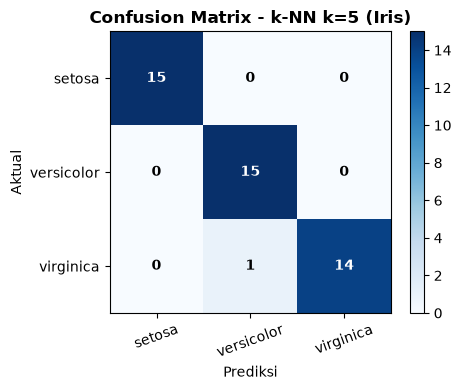

In [ ]:
cm_knn = confusion_matrix(yi_test, knn_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_knn, cmap='Blues')
ax.set_xticks(range(3)); ax.set_xticklabels(iris.target_names, rotation=20)
ax.set_yticks(range(3)); ax.set_yticklabels(iris.target_names)
ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')
ax.set_title('Confusion Matrix - k-NN k=5 (Iris)', fontweight='bold')
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm_knn[i, j], ha='center', va='center',
                color='white' if cm_knn[i, j] > cm_knn.max()/2 else 'black', fontweight='bold')
plt.colorbar(im)
plt.tight_layout()
plt.show()

**Prediksi data bunga baru:**

In [10]:
bunga_baru = pd.DataFrame([[5.0, 3.4, 1.5, 0.2]], columns=iris.feature_names)
pred_bunga = knn.predict(bunga_baru)
print('Prediksi kelas:', iris.target_names[pred_bunga[0]])

Prediksi kelas: setosa


## 4.8 Eksperimen: Pencarian Nilai k Optimal

In [11]:
k_range = range(1, 21)
k_scores = []
for k in k_range:
    c = KNeighborsClassifier(n_neighbors=k)
    c.fit(Xi_train, yi_train)
    acc = accuracy_score(yi_test, c.predict(Xi_test))
    k_scores.append(acc)
    print(f'k={k}: akurasi = {acc:.4f}')

k=1: akurasi = 0.9333
k=2: akurasi = 0.9111
k=3: akurasi = 0.9556
k=4: akurasi = 0.9556
k=5: akurasi = 0.9778
k=6: akurasi = 0.9556
k=7: akurasi = 0.9556
k=8: akurasi = 0.9333
k=9: akurasi = 0.9556
k=10: akurasi = 0.9556
k=11: akurasi = 0.9333
k=12: akurasi = 0.9333
k=13: akurasi = 0.9333
k=14: akurasi = 0.9333
k=15: akurasi = 0.9556
k=16: akurasi = 0.9556
k=17: akurasi = 0.9556
k=18: akurasi = 0.9556
k=19: akurasi = 0.9556
k=20: akurasi = 0.9333


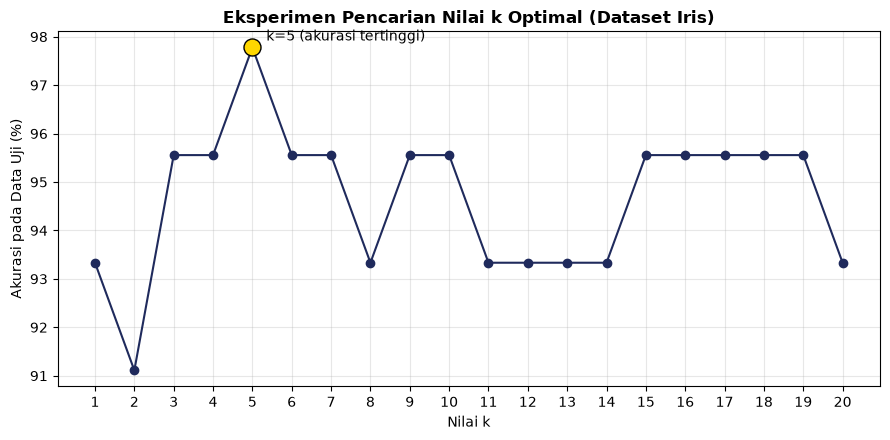

In [ ]:
best_k = list(k_range)[int(np.argmax(k_scores))]
plt.figure(figsize=(9, 4.5))
plt.plot(list(k_range), [s*100 for s in k_scores], marker='o', color='#1f2a5c')
plt.scatter([best_k], [max(k_scores)*100], s=150, color='gold', edgecolor='black', zorder=5)
plt.annotate(f'k={best_k} (akurasi tertinggi)', (best_k, max(k_scores)*100),
             textcoords='offset points', xytext=(10, 5))
plt.xticks(list(k_range))
plt.xlabel('Nilai k'); plt.ylabel('Akurasi pada Data Uji (%)')
plt.title('Eksperimen Pencarian Nilai k Optimal (Dataset Iris)', fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4.9 Perbandingan Naive Bayes vs k-NN

In [13]:
print('Naive Bayes (Gaussian):', accuracy_score(yi_test, nb_pred))
print('k-NN (k=5):', accuracy_score(yi_test, knn_pred))

Naive Bayes (Gaussian): 0.9111111111111111
k-NN (k=5): 0.9777777777777777


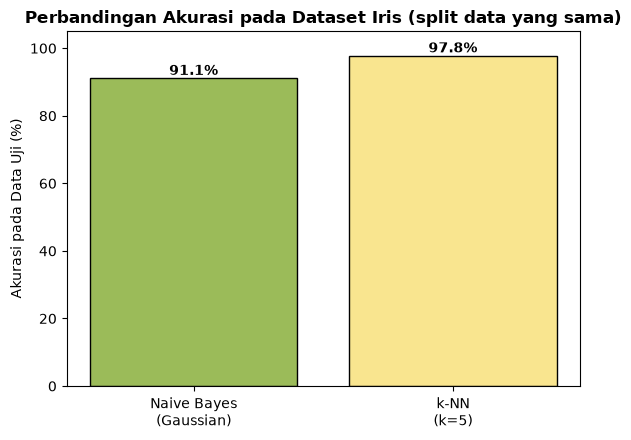

In [ ]:
akurasi = [accuracy_score(yi_test, nb_pred)*100, accuracy_score(yi_test, knn_pred)*100]
plt.figure(figsize=(6, 4.5))
bars = plt.bar(['Naive Bayes\n(Gaussian)', 'k-NN\n(k=5)'], akurasi,
               color=['#9bbb59', '#f9e58f'], edgecolor='black')
for b, a in zip(bars, akurasi):
    plt.text(b.get_x() + b.get_width()/2, a + 1, f'{a:.1f}%', ha='center', fontweight='bold')
plt.ylim(0, 105)
plt.ylabel('Akurasi pada Data Uji (%)')
plt.title('Perbandingan Akurasi pada Dataset Iris (split data yang sama)', fontweight='bold')
plt.tight_layout()
plt.show()

## Tugas 1 – Variasi Varian Naive Bayes

In [15]:
# 1. Menggunakan OneHotEncoder dan BernoulliNB pada dataset Play Tennis

import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.naive_bayes import BernoulliNB

# Asumsi dataframe Play Tennis sudah diload sebagai df
fitur = ['Outlook', 'Temperature', 'Humidity', 'Wind']
X = df[fitur].copy()
y = df['PlayTennis'].copy()

# Menggunakan OneHotEncoder (BernoulliNB butuh input biner)
ohe = OneHotEncoder(sparse_output=False)
X_ohe = ohe.fit_transform(X)

clf_bnb = BernoulliNB()
clf_bnb.fit(X_ohe, y)

# Prediksi data baru
data_baru = pd.DataFrame([{
    'Outlook': 'Sunny', 'Temperature': 'Cool',
    'Humidity': 'High', 'Wind': 'Strong'
}])
data_baru_ohe = ohe.transform(data_baru)

pred_bnb = clf_bnb.predict(data_baru_ohe)
proba_bnb = clf_bnb.predict_proba(data_baru_ohe)

print(f"Prediksi BernoulliNB: {pred_bnb[0]}")
print(f"Probabilitas BernoulliNB: {dict(zip(clf_bnb.classes_, proba_bnb[0].round(4)))}")

Prediksi BernoulliNB: No
Probabilitas BernoulliNB: {np.str_('No'): np.float64(0.9101), np.str_('Yes'): np.float64(0.0899)}


In [16]:
# 2. Menambahkan 3 baris data baru dan mengecek probabilitas Prior

# Tambah 3 baris baru
df_baru = pd.DataFrame([
    {'Day': 'D15', 'Outlook': 'Rain', 'Temperature': 'Hot', 'Humidity': 'Normal', 'Wind': 'Weak', 'PlayTennis': 'Yes'},
    {'Day': 'D16', 'Outlook': 'Overcast', 'Temperature': 'Cool', 'Humidity': 'High', 'Wind': 'Strong', 'PlayTennis': 'No'},
    {'Day': 'D17', 'Outlook': 'Sunny', 'Temperature': 'Mild', 'Humidity': 'High', 'Wind': 'Strong', 'PlayTennis': 'No'}
])
df_ext = pd.concat([df, df_baru], ignore_index=True)
print(df_ext['PlayTennis'].value_counts(normalize=True))

PlayTennis
Yes    0.588235
No     0.411765
Name: proportion, dtype: float64


## Tugas 2 — Evaluasi Mendalam k-NN 

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# 1. k-NN dengan Manhattan distance
knn_manhattan = KNeighborsClassifier(n_neighbors=5, metric='manhattan')
knn_manhattan.fit(Xi_train, yi_train)
acc_manhattan = accuracy_score(yi_test, knn_manhattan.predict(Xi_test))
print(f"Akurasi k-NN (Manhattan, k=5): {acc_manhattan:.4f}")

# 2. k-NN dengan StandardScaler
scaler = StandardScaler()
Xi_train_scaled = scaler.fit_transform(Xi_train)
Xi_test_scaled = scaler.transform(Xi_test)

knn_scaled = KNeighborsClassifier(n_neighbors=5) 
knn_scaled.fit(Xi_train_scaled, yi_train)
acc_scaled = accuracy_score(yi_test, knn_scaled.predict(Xi_test_scaled))
print(f"Akurasi k-NN (StandardScaler + Euclidean, k=5): {acc_scaled:.4f}")

Akurasi k-NN (Manhattan, k=5): 0.9333
Akurasi k-NN (StandardScaler + Euclidean, k=5): 0.9111


## Tugas 3 — Dataset Baru 

In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

df_padi = pd.read_csv('Data_Tanaman_Padi_Sumatera.csv', sep=';')

# Buat atribut target kategorikal
median_produksi = df_padi['Produksi'].median()
df_padi['Kategori Produksi'] = np.where(df_padi['Produksi'] > median_produksi, 'Tinggi', 'Rendah')

fitur_padi = ['Luas Panen', 'Curah hujan', 'Kelembapan', 'Suhu rata-rata']
X_padi = df_padi[fitur_padi]
y_padi = df_padi['Kategori Produksi']

Xp_train, Xp_test, yp_train, yp_test = train_test_split(X_padi, y_padi, test_size=0.3, random_state=42, stratify=y_padi)

# Naive Bayes (Gaussian)
nb_padi = GaussianNB()
nb_padi.fit(Xp_train, yp_train)
acc_nbp = accuracy_score(yp_test, nb_padi.predict(Xp_test))
print(f"Akurasi Naive Bayes (Padi): {acc_nbp:.4f}")

# k-NN
knn_padi = KNeighborsClassifier(n_neighbors=5)
knn_padi.fit(Xp_train, yp_train)
acc_knnp = accuracy_score(yp_test, knn_padi.predict(Xp_test))
print(f"Akurasi k-NN (Padi): {acc_knnp:.4f}")

Akurasi Naive Bayes (Padi): 0.9265
Akurasi k-NN (Padi): 0.9265
